# California Housing - Modeling

**DATA 4950 Week 11 Demo**

## What We Will Cover


1. Load preprocessed data
2. Baseline model (Simple Train/Test)
3. Advanced models (Simple Train/Test)
4. Cross-validation
5. Hyperparameter tuning (GridSearchCV)
6. Final model comparision
7. Save the best model

In [1]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

In [2]:
# load data from preprocessing notebook
X_train_base = pd.read_csv('../data/processed/X_train.csv')
X_test_base = pd.read_csv('../data/processed/X_test.csv')
y_train_base = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test_base = pd.read_csv('../data/processed/y_test.csv').squeeze()

In [3]:
# load data from feature engineering notebook
X_train = pd.read_csv('../data/modeling/X_train.csv')
X_test = pd.read_csv('../data/modeling/X_test.csv')
y_train = pd.read_csv('../data/modeling/y_train.csv').squeeze()
y_test = pd.read_csv('../data/modeling/y_test.csv').squeeze()

## save WITH SCALE
X_train_standard = pd.read_csv('../data/modeling/X_train_standard.csv')
X_test_standard = pd.read_csv('../data/modeling/X_test_standard.csv')

print(f'Training (original): {X_train.shape}')
print(f'Training (Standard):    {X_train_standard.shape}')
print(f'Test:                {X_test.shape}')

Training (original): (16168, 16)
Training (Standard):    (16168, 16)
Test:                (4042, 16)


## Basic Models

Start simple. Build complexity gradually.

In [4]:
## store results
results = []

### model 1: Linear Regression 

#### Data after preprocessing

In [5]:
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()
baseline_model.fit(X_train_base, y_train_base)



LinearRegression()

In [6]:
y_train_pred_base = baseline_model.predict(X_train_base)

In [7]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_train_base = r2_score(y_train_base, y_train_pred_base)
rmse_train_base = np.sqrt(mean_squared_error(y_train_base, y_train_pred_base))

print(f'Baseline Linear Regression on train set: R² = {r2_train_base:.4f}, RMSE = {rmse_train_base:.4f}')

Baseline Linear Regression on train set: R² = 0.6651, RMSE = 66893.4164


In [8]:
y_pred_base = baseline_model.predict(X_test_base)

In [9]:
r2_base = r2_score(y_test_base, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test_base, y_pred_base))

results.append({'Model': 'Baseline Linear Regression', 'R²': r2_base, 'RMSE': rmse_base})
print(f'Baseline Linear Regression on test set: R² = {r2_base:.4f}, RMSE = {rmse_base:.4f}')

Baseline Linear Regression on test set: R² = 0.6616, RMSE = 66670.4241


#### Data in Feature Engineering

In [10]:
lr_fe = LinearRegression()
lr_fe.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred_lrfe = lr_fe.predict(X_test)

In [12]:
r2_lrfe = r2_score(y_test, y_pred_lrfe)
rmse_lrfe = np.sqrt(mean_squared_error(y_test, y_pred_lrfe))

results.append({'Model': 'No Scaling Linear Regression', 'R²': r2_lrfe, 'RMSE': rmse_lrfe})
print(f'No Scaling Linear Regression: R² = {r2_lrfe:.4f}, RMSE = {rmse_lrfe:.4f}')

No Scaling Linear Regression: R² = 0.6921, RMSE = 63595.3396


#### Data in Feature Engineering with Scale

In [13]:
lr = LinearRegression()
lr.fit(X_train_standard, y_train)

LinearRegression()

In [14]:
y_pred_lr = lr.predict(X_test_standard)

In [15]:
r2_lr  = r2_score(y_test, y_pred_lr )
rmse_lr  = np.sqrt(mean_squared_error(y_test, y_pred_lr ))

results.append({'Model': 'Scaling Linear Regression', 'R²': r2_lr , 'RMSE': rmse_lr })
print(f'Linear Regression: R² = {r2_lr :.4f}, RMSE = {rmse_lr :.4f}')

Linear Regression: R² = 0.6921, RMSE = 63595.3396


### model 2: Ridge Regression

Linear regression with L2 regularization. Helps prevent overfitting.

#### Data in Feature Engineering

In [16]:
from sklearn.linear_model import  Ridge

In [17]:
ridge_fe = Ridge(alpha=1.0)


## TODO: ridge regression with both noscaled and scaled data



Ridge()

No Scaling Ridge: R² = 0.6918, RMSE = 63627.7240


#### Data in Feature Engineering with Scale

In [20]:
ridge = Ridge(alpha=1.0)




Ridge()

Ridge: R² = 0.6921, RMSE = 63595.9116


### model 3: Lasso Regression 

Linear regression with L1 regularization. Can do feature selection.

#### Data in Feature Engineering

In [64]:
from sklearn.linear_model import  Lasso

lasso = Lasso(alpha=0.01)

## TODO: Lasso regression with both noscaled and scaled data




Lasso(alpha=0.01)

Lasso: R² = 0.6921, RMSE = 63595.3403


#### Data in Feature Engineering with Scale

In [26]:
lasso = Lasso(alpha=0.01)



Lasso: R² = 0.6921, RMSE = 63595.3413


### model 4: Decision Tree

In [27]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=4950)

## TODO: Decision Tree with both noscaled and scaled data




DecisionTreeRegressor(max_depth=10, random_state=4950)

Decision Tree: R² = 0.6922, RMSE = 63587.0736


In [30]:
dt = DecisionTreeRegressor(max_depth=10, random_state=4950)



Decision Tree: R² = 0.6900, RMSE = 63811.4689


Scaling may hurt the performance of tree-based model. They should be trained on unscaled data.

### model 5: Random Forest

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=4950, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=4950)

In [32]:
y_pred_rf = rf.predict(X_test)

In [33]:
r2 = r2_score(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

results.append({'Model': 'No Scaling Random Forest', 'R²': r2, 'RMSE': rmse})
print(f'Random Forest: R² = {r2:.4f}, RMSE = {rmse:.4f}')

Random Forest: R² = 0.8067, RMSE = 50387.2003


### model 6: Gradient Boosting

In [34]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                               learning_rate=0.1, random_state=4950)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
r2 = r2_score(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

results.append({'Model': 'No Scaling Gradient Boosting', 'R²': r2, 'RMSE': rmse})
print(f'Gradient Boosting: R² = {r2:.4f}, RMSE = {rmse:.4f}')

Gradient Boosting: R² = 0.8085, RMSE = 50158.9956


In [35]:
## TODO: create comparison table




Model Comparison
                       Model       R²         RMSE
No Scaling Gradient Boosting 0.808483 50158.995624
    No Scaling Random Forest 0.806737 50387.200254
    No Scaling Decision Tree 0.692216 63587.073558
   Scaling Linear Regression 0.692136 63595.339627
No Scaling Linear Regression 0.692136 63595.339627
            No Scaling Lasso 0.692136 63595.340263
               Scaling Lasso 0.692136 63595.341281
               Scaling Ridge 0.692130 63595.911627
            No Scaling Ridge 0.691822 63627.724001
       Scaling Decision Tree 0.690039 63811.468874
  Baseline Linear Regression 0.661643 66670.424121


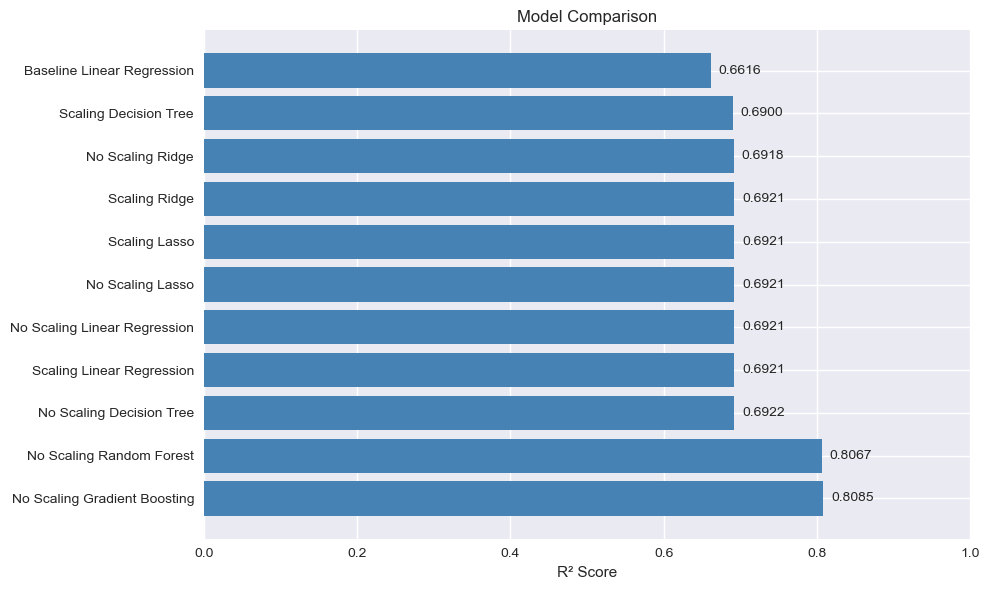

In [36]:
## TODO: create barplot of the R2 for all methods
fig, ax = plt.subplots(figsize=(10, 6))






## Feature Refinement — Dropping Uninformative Features

More features ≠ better model. Extra features add noise and slow training.
We use two complementary methods to identify candidates for removal:

1. **Correlation with target** — a feature with |r| < 0.05 carries almost no signal
2. **Lasso coefficients** — features zeroed out by Lasso are redundant (given others)
3. **Inter-feature correlation** — if two features correlate > 0.85 with each other,
   keeping both is redundant (multicollinearity inflates variance in linear models)
4. **Feature importance** based on tree models

In [37]:
# Step 1: find features with absolute correlation < 0.05

correlation_matrix = pd.concat([X_train_standard,y_train],axis=1).corr()
correlations = correlation_matrix['median_house_value'].abs().sort_values(ascending=False)
correlations = correlations.drop('median_house_value')
correlations

MedInc                 0.691857
IncomeCategory         0.658672
RoomsPerPerson         0.412652
AveRooms               0.314524
AveOccup               0.279587
Region_North           0.252290
BedroomRatio           0.248038
Latitude               0.143751
Region_South           0.138835
DistToLA               0.129513
HouseAge               0.105821
AveBedrms              0.098091
AgeCategory_encoded    0.061077
Longitude              0.044926
Population             0.035938
DistToSF               0.028625
Name: median_house_value, dtype: float64

In [38]:
# Step 2: Lasso zeroed-out features (from Lasso regression)
zeroed = X_train_standard.columns[lasso.coef_ == 0].tolist()
print("Features zeroed by Lasso:", zeroed if zeroed else "none at alpha=0.01")


Features zeroed by Lasso: none at alpha=0.01


In [39]:
# Step 3: find pairs with absolute correlation > 0.85
correlation_matrix_abs = correlation_matrix.abs()
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range (i+1, len(correlation_matrix.columns)):
        if correlation_matrix_abs.iloc[i,j]>0.85:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i,j]))

In [40]:
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df = high_corr_df.sort_values(by="Correlation", ascending=False).reset_index(drop=True)

print("Highly correlated feature pairs (>0.85):")
high_corr_df

Highly correlated feature pairs (>0.85):


,Feature 1,Feature 2,Correlation
0,Longitude,DistToSF,0.954635
1,MedInc,IncomeCategory,0.946511
2,Latitude,DistToLA,0.941632
3,DistToSF,Region_South,0.923799
4,Longitude,Region_South,0.890056
5,HouseAge,AgeCategory_encoded,0.870048
6,AveRooms,BedroomRatio,-0.885645
7,Longitude,DistToLA,-0.892450
8,Latitude,DistToSF,-0.898018
9,DistToLA,Region_South,-0.906162


In [41]:
high_corr_df.sort_values(by='Feature 1')

,Feature 1,Feature 2,Correlation
6,AveRooms,BedroomRatio,-0.885645
9,DistToLA,Region_South,-0.906162
3,DistToSF,Region_South,0.923799
5,HouseAge,AgeCategory_encoded,0.870048
2,Latitude,DistToLA,0.941632
8,Latitude,DistToSF,-0.898018
10,Latitude,Region_South,-0.923367
11,Latitude,Longitude,-0.924640
0,Longitude,DistToSF,0.954635
4,Longitude,Region_South,0.890056


In [42]:
## Step 4: feature importance 
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances

MedInc                 0.518687
HouseAge               0.037333
AveRooms               0.013068
AveBedrms              0.015987
Population             0.021565
AveOccup               0.120628
Latitude               0.055526
Longitude              0.044661
IncomeCategory         0.000511
RoomsPerPerson         0.028051
BedroomRatio           0.019734
DistToSF               0.070105
DistToLA               0.051909
AgeCategory_encoded    0.001159
Region_North           0.000799
Region_South           0.000278
dtype: float64

<Axes: >

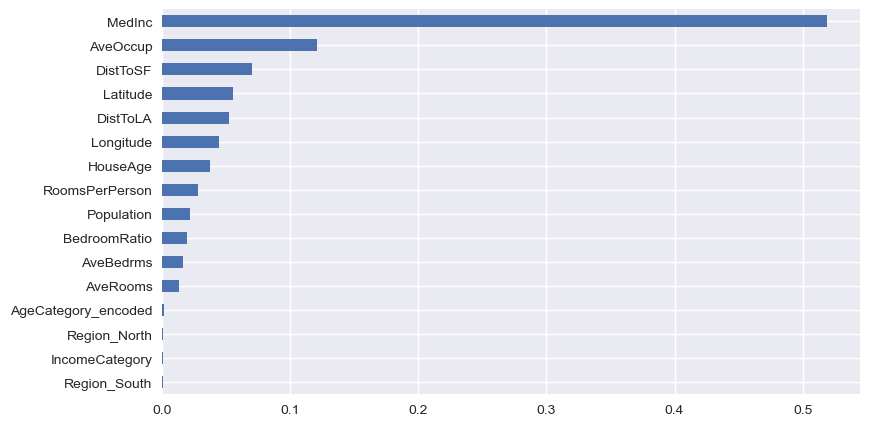

In [43]:
importances.sort_values(ascending=True).plot.barh(figsize=(9, 5))

###  Drop candidates

Based on the three diagnostics above, we will remove:

| Feature | Reason |
|---------|--------|
| `Population` | $|r|$ ≈ 0.04 — near-zero signal with target |
| `Region_North`, `Region_South` | Redundant: $|r|$ > 0.85 with `DisttoLA` and `Latitude`-based features |
| `BedroomRatio` | Absorbed by `RoomsPerPerson`; weak additional signal |
| `IncomeCategory` | Redundant: $|r|$ > 0.85 with 'MedInc' |

We keep at most **one** of each highly correlated geographic pair.


In [ ]:
# TODO: discussion features to drop
drop_cols = 





# Drop only the columns that actually exist in this dataset
drop_cols = [c for c in drop_cols if c in X_train.columns]
print(f"Dropping: {drop_cols}")

X_train_refined = X_train.drop(columns=drop_cols)
X_test_refined = X_test.drop(columns=drop_cols)

# For linear models, re-scale the refined set
from sklearn.preprocessing import StandardScaler
scaler_refined = StandardScaler()
X_train_refined_std = pd.DataFrame(
    scaler_refined.fit_transform(X_train_refined),columns=X_train_refined.columns)
X_test_refined_std  = pd.DataFrame(
    scaler_refined.transform(X_test_refined),columns=X_test_refined.columns)

print(f"Features: {X_train.shape[1]} → {X_train_refined.shape[1]}")


###  Compare performance before vs after dropping

In [45]:
# TODO: Re-train key models on refined feature set







            Model  Full features  Refined features    Δ R²
Linear Regression         0.6921            0.6866 -0.0055
    Random Forest         0.8067            0.8050 -0.0017
Gradient Boosting         0.8085            0.8071 -0.0014


## Introduce KFold

The Problem: Can We Trust One Split?

In [66]:
from sklearn.model_selection import KFold, cross_val_score

In [67]:
cv = KFold(n_splits=5, shuffle=True, random_state=4950)

In [68]:
from sklearn.pipeline import make_pipeline

cv_results = []

# Linear Regression
lr_pipe = make_pipeline(StandardScaler(), LinearRegression())
scores = cross_val_score(lr_pipe, X_train_refined, y_train, cv=cv, scoring='r2', n_jobs=-1)
cv_results.append({'Model': 'Linear Regression', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print(f"Linear Regression      mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")

Linear Regression      mean=0.6889  std=0.0074  folds=[0.698 0.689 0.686 0.695 0.677]


In [69]:
# TODO: Ridge





Ridge (α=1)            mean=0.6889  std=0.0074  folds=[0.698 0.689 0.686 0.695 0.677]


In [70]:
# Lasso
lasso_pipe = make_pipeline(StandardScaler(), Lasso(alpha=0.01))
scores = cross_val_score(lasso_pipe, X_train_refined, y_train, cv=cv, scoring='r2', n_jobs=-1)
cv_results.append({'Model': 'Lasso (α=0.01)', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print(f"Lasso (α=0.01)         mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")

Lasso (α=0.01)         mean=0.6889  std=0.0074  folds=[0.698 0.689 0.686 0.695 0.677]


In [71]:
# Random Forest
rf_cv = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=4950, n_jobs=-1)
scores = cross_val_score(rf_cv, X_train_refined, y_train, cv=cv, scoring='r2', n_jobs=-1)
cv_results.append({'Model': 'Random Forest', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print(f"Random Forest          mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")

Random Forest          mean=0.8105  std=0.0037  folds=[0.808 0.815 0.81  0.815 0.805]


In [72]:
# TODO: Gradient Boosting






Gradient Boosting      mean=0.8115  std=0.0056  folds=[0.808 0.812 0.813 0.821 0.804]


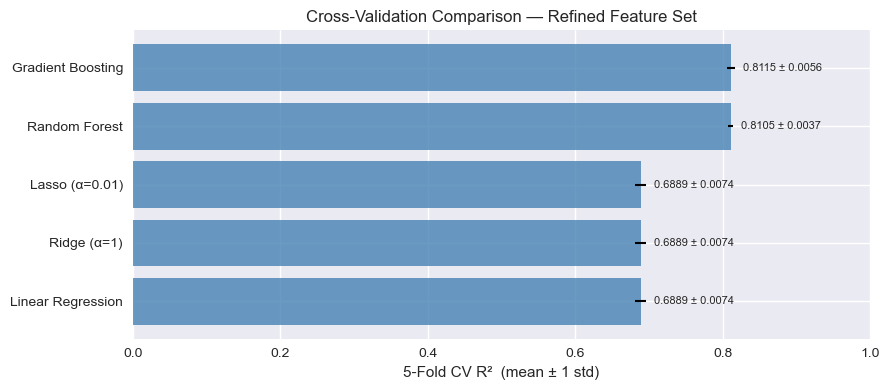

In [73]:
# Visualise CV mean ± 1 std
cv_df = pd.DataFrame(cv_results).sort_values('CV Mean R²', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cv_df['Model'], cv_df['CV Mean R²'],
        xerr=cv_df['CV Std'], color='steelblue', alpha=0.8,
        error_kw=dict(ecolor='black', capsize=5, lw=1.5))
ax.set_xlabel('5-Fold CV R²  (mean ± 1 std)')
ax.set_title('Cross-Validation Comparison — Refined Feature Set')
ax.set_xlim(0, 1.0)
for i, row in cv_df.iterrows():
    ax.text(row['CV Mean R²'] + row['CV Std'] + 0.01,
            list(cv_df.index).index(i),
            f"{row['CV Mean R²']:.4f} ± {row['CV Std']:.4f}",
            va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning with GridSearchCV